In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
filepath = "data/gen9ou-0.txt"
#define filepath for future use

In [37]:
with open(filepath, 'r') as f:
    lines = f.readlines()

    data_lines = [line.strip() for line in lines if '|' in line and "Rank" 
    not in line and "---" not in line]
    #filters out where data actually begins

    #split by pipe
    rows = [line.split('|')[1:-1] for line in data_lines]
    rows = [[cell.strip() for cell in row] for row in rows]

    columns = ["Rank", "Pokemon", "Usage %", "Raw", "Raw %", "Real", "Real %"]

    stats_df = pd.DataFrame(rows, columns=columns)
    #df created

    #convert rows to numeric
    stats_df["Rank"] = stats_df["Rank"].astype(int)
    stats_df["Usage %"] = stats_df["Usage %"].str.replace('%', '').astype(float)
    stats_df["Raw"] = stats_df["Raw"].astype(int)
    stats_df["Raw %"] = stats_df["Raw %"].str.replace('%', '').astype(float)
    stats_df["Real"] = stats_df["Real"].astype(int)
    stats_df["Real %"] = stats_df["Real %"].str.replace('%', '').astype(float)



In [38]:
stats_df.head()

,Rank,Pokemon,Usage %,Raw,Raw %,Real,Real %
0,1,Great Tusk,28.68381,602878,28.684,479220,28.641
1,2,Kingambit,18.79622,395060,18.796,271084,16.201
2,3,Gholdengo,18.59330,390795,18.593,300632,17.967
3,4,Dragapult,14.95804,314389,14.958,246596,14.738
4,5,Dragonite,14.68347,308618,14.683,228337,13.647


In [39]:
stats_df = stats_df.set_index("Rank")
stats_df_cleaned = stats_df[['Pokemon', 'Usage %']]
stats_df_cleaned

#filter out only rank and usage stats. those are the only important things to me

,Pokemon,Usage %
Rank,,
1,Great Tusk,28.68381
2,Kingambit,18.79622
3,Gholdengo,18.59330
4,Dragapult,14.95804
5,Dragonite,14.68347
...,...,...
745,Pawmo,0.00005
746,Arrokuda,0.00005
747,Rockruff,0.00005


In [40]:
role_map = {
    "Great Tusk": "Hazard Removal",
    "Kingambit": "Sweeper",
    "Gholdengo": "Wallbreaker",
    "Dragapult": "Pivot",
    "Dragonite": "Sweeper",
    "Ogerpon-Wellspring": "Wallbreaker",
    "Iron Valiant": "Sweeper",
    "Zamazenta": "Sweeper",
    "Slowking-Galar": "Pivot",
    "Corviknight": "Pivot",
    "Gliscor": "Wall",
    "Raging Bolt": "Wallbreaker",
    "Hatterene": "Hazard Removal",
    "Landorus-Therian": "Pivot",
    "Cinderace": "Pivot",
    "Iron Treads": "Hazard Lead",
    "Alomomola": "Pivot",
    "Glimmora": "Hazard Lead",
    "Kyurem": "Wallbreaker",
    "Ceruledge": "Sweeper",
    "Samurott-Hisui": "Hazard Lead",
    "Scizor": "Pivot",
    "Ting-Lu": "Wall",
    "Darkrai": "Sweeper",
    "Rillaboom": "Pivot",
    "Garganacl": "Wall",
    "Iron Moth": "Sweeper",
    "Zapdos": "Pivot",
    "Pecharunt": "Pivot",
    "Walking Wake": "Wallbreaker",
    "Garchomp": "Hazard Stack",
    "Tyranitar": "Wallbreaker",
    "Heatran": "Wallbreaker",
    "Primarina": "Pivot",
    "Clefable": "Pivot",
    "Moltres": "Pivot",
    "Enamorus": "Sweeper",
    "Deoxys-Speed": "Sweeper",
    "Meowscarada": "Pivot",
    "Excadrill": "Sweeper",
    "Weezing-Galar": "Pivot",
    "Iron Crown": "Pivot",
    "Torkoal": "Weather Setter",
    "Pelipper": "Weather Setter",
    "Dondozo": "Wall",
    "Toxapex": "Pivot",
    "Tornadus-Therian": "Pivot",
    "Hydrapple": "Wallbreaker",
    "Clodsire": "Wall",
    "Greninja": "Sweeper",
    "Blaziken": "Sweeper",
    "Ninetales-Alola": "Weather Setter",
    "Ursaluna": "Wallbreaker",
    "Serperior": "Sweeper",
    "Araquanid": "Hazard Lead",
    "Hoopa-Unbound": "Wallbreaker",
    "Blissey": "Wall",
    "Weavile": "Wallbreaker",
    "Ninetales": "Weather Setter",
    "Skeledirge": "Wall",
    "Lokix": "Wallbreaker",
    "Rotom-Wash": "Pivot",
    "Quaquaval": "Sweeper",
    "Latios": "Wallbreaker",
    "Sinistcha": "Utility",
    "Venusaur": "Sweeper",
    "Tinkaton": "Utility",
    "Grimmsnarl": "Utility",
    "Iron Hands": "Pivot",
    "Ribombee": "Hazard Lead",
    "Skarmory": "Wall",
    "Volcanion": "Wallbreaker",
    "Gengar": "Sweeper",
    "Goodra-Hisui": "Wall",
    "Barraskewda": "Sweeper",
    "Arcanine-Hisui": "Wallbreaker",
    "Mimikyu": "Sweeper",
    "Ogerpon-Cornerstone": "Sweeper",
    "Zoroark-Hisui": "Wallbreaker",
    "Hawlucha": "Sweeper",
    "Ogerpon": "Wallbreaker",
    "Umbreon": "Wall",
    "Keldeo": "Wallbreaker",
    "Metagross": "Wallbreaker",
    "Maushold": "Hazard Removal",
    "Polteageist": "Sweeper",
    "Iron Boulder": "Sweeper",
    "Incineroar": "Pivot",
    "Indeedee": "Utility",
    "Moltres-Galar": "Sweeper",
    "Slither Wing": "Wallbreaker",
    "Azumarill": "Wallbreaker",
    "Thundurus-Therian": "Sweeper",
    "Latias": "Sweeper",
    "Gyarados": "Sweeper",
    "Kommo-o": "Sweeper",
    "Hydreigon": "Wallbreaker",
    "Cresselia": "Wall",
    "Cloyster": "Sweeper",
    "Mandibuzz": "Pivot",
    "Comfey": "Sweeper",
    "Galvantula": "Hazard Lead",
    "Lilligant-Hisui": "Sweeper",
    "Gardevoir": "Wallbreaker",
    "Conkeldurr": "Wallbreaker",
    "Charizard": "Sweeper",
    "Talonflame": "Pivot",
    "Haxorus": "Sweeper",
    "Chesnaught": "Hazard Stack",
    "Blastoise": "Hazard Removal",
    "Jolteon": "Pivot",
    "Salamence": "Sweeper",
    "Kingdra": "Sweeper",
    "Mamoswine": "Wallbreaker",
    "Espeon": "Utility",
    "Okidogi": "Wallbreaker",
    "Milotic": "Wall",
    "Sandy Shocks": "Hazard Stack",
    "Magnezone": "Wallbreaker",
    "Manaphy": "Sweeper",
    "Amoonguss": "Wall",
    "Chandelure": "Wallbreaker",
    "Kleavor": "Hazard Lead",
    "Forretress": "Hazard Removal",
    "Armarouge": "Wallbreaker",
    "Jirachi": "Pivot",
    "Bronzong": "Wall",
    "Ditto": "Utility",
    "Toxicroak": "Sweeper",
    "Empoleon": "Hazard Removal",
    "Lucario": "Sweeper",
    "Infernape": "Pivot",
    "Whimsicott": "Utility",
    "Mew": "Utility",
    "Slowking": "Pivot",
    "Fezandipiti": "Pivot",
    "Muk-Alola": "Wall",
    "Snorlax": "Wall",
    "Chansey": "Wall",
    "Pawmot": "Wallbreaker",
    "Swampert": "Pivot",
    "Gastrodon": "Wall",
    "Reuniclus": "Sweeper",
    "Breloom": "Wallbreaker",
    "Salazzle": "Sweeper",
    "Gallade": "Sweeper",
    "Porygon2": "Wall",
    "Porygon-Z": "Sweeper",
    "Tentacruel": "Hazard Removal",
    "Sylveon": "Wall",
    "Hippowdon": "Weather Setter",
    "Regidrago": "Wallbreaker",
    "Krookodile": "Pivot",
    "Torterra": "Sweeper",
    "Zapdos-Galar": "Sweeper",
    "Sableye": "Utility",
    "Deoxys-Defense": "Hazard Lead",
    "Crawdaunt": "Wallbreaker",
    "Quagsire": "Wall",
    "Vaporeon": "Wall",
    "Toxtricity": "Wallbreaker",
    "Sceptile": "Sweeper",
    "Noivern": "Pivot",
    "Kilowattrel": "Pivot",
    "Bisharp": "Sweeper",
    "Donphan": "Hazard Removal",
    "Basculegion": "Sweeper",
    "Thundurus": "Sweeper",
    "Staraptor": "Wallbreaker",
    "Vileplume": "Wall",
    "Frosmoth": "Sweeper",
    "Pincurchin": "Utility",
    "Feraligatr": "Sweeper",
    "Rotom-Heat": "Pivot",
    "Decidueye-Hisui": "Wallbreaker",
    "Ambipom": "Pivot",
    "Klefki": "Utility",
    "Politoed": "Weather Setter",
    "Slowbro": "Pivot",
    "Arcanine": "Pivot",
    "Iron Jugulis": "Sweeper",
    "Vikavolt": "Wallbreaker",
    "Eelektross": "Pivot",
    "Diancie": "Utility",
    "Smeargle": "Hazard Lead",
    "Inteleon": "Sweeper",
    "Lycanroc-Dusk": "Hazard Lead",
    "Cetitan": "Sweeper",
    "Malamar": "Sweeper",
    "Overqwil": "Hazard Stack",
    "Grafaiai": "Utility",
    "Goodra": "Wall",
    "Heracross": "Wallbreaker",
    "Typhlosion-Hisui": "Wallbreaker",
    "Scream Tail": "Utility",
    "Cyclizar": "Pivot",
    "Tsareena": "Hazard Removal",
    "Pikachu": "Unviable",
    "Yanmega": "Sweeper",
    "Cinccino": "Sweeper",
    "Mienshao": "Pivot",
    "Dragalge": "Wallbreaker"

}

with_roles = stats_df_cleaned.copy()
with_roles['Role'] = with_roles['Pokemon'].map(role_map)

with_roles.loc[with_roles['Role'].isna() & (with_roles['Usage %'] < 0.3), 'Role'] = 'Unviable'


#yes these pokemon have multiple sets. dd kyurem is a thing and deadly. we are 
#just using the most common ones for now
with_roles


,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,28.68381,Hazard Removal
2,Kingambit,18.79622,Sweeper
3,Gholdengo,18.59330,Wallbreaker
4,Dragapult,14.95804,Pivot
5,Dragonite,14.68347,Sweeper
...,...,...,...
745,Pawmo,0.00005,Unviable
746,Arrokuda,0.00005,Unviable
747,Rockruff,0.00005,Unviable


In [41]:
in_ou = ["Alomomola", "Ceruledge", "Cinderace", "Clefable", "Corviknight", "Darkrai", "Deoxys-Speed", "Dondozo",
         "Dragapult", "Dragonite", "Enamorus", "Garganacl", "Gholdengo", "Glimmora", "Gliscor", "Great Tusk",
         "Hatterene", "Heatran", "Iron Crown", "Iron Moth", "Iron Treads", "Iron Valiant", "Kingambit", "Kyurem", "Landorus-Therian",
         "Moltres", "Ogerpon-Wellspring", "Pecharunt", "Primarina", "Raging Bolt", "Rillaboom", "Samurott-Hisui", "Slowking-Galar"
         "Ting-Lu", "Tornadus-Therian", "Tyranitar", "Walking Wake", "Weezing-Galar", "Zamazenta", "Zapdos"]

#just snipping down to only pokemon in OU for some experimentation

ou_set = set(in_ou)
ou_df = with_roles[with_roles["Pokemon"].isin(ou_set)].copy()

ou_df

,Pokemon,Usage %,Role
Rank,,,
1,Great Tusk,28.68381,Hazard Removal
2,Kingambit,18.79622,Sweeper
3,Gholdengo,18.59330,Wallbreaker
4,Dragapult,14.95804,Pivot
5,Dragonite,14.68347,Sweeper
6,Iron Valiant,13.72301,Sweeper
7,Ogerpon-Wellspring,13.58313,Wallbreaker
8,Corviknight,12.05701,Pivot
10,Raging Bolt,11.50872,Wallbreaker


In [42]:
gen_origin = {
    "Alomomola": 5,
    "Ceruledge": 9,
    "Cinderace": 8,
    "Clefable": 1,
    "Darkrai": 4,
    "Deoxys-Speed": 3,
    "Dondozo": 9,
    "Dragapult": 8,
    "Dragonite": 1,
    "Enamorus": 8,
    "Garganacl": 9,
    "Gholdengo": 9,
    "Glimmora": 9,
    "Gliscor": 2,
    "Great Tusk": 9,
    "Hatterene": 8,
    "Heatran": 4,
    "Iron Crown": 9,
    "Iron Moth": 9,
    "Iron Treads": 9,
    "Iron Valiant": 9,
    "Kingambit": 9,
    "Kyurem": 5,
    "Moltres": 1,
    "Ogerpon-Wellspring": 9,
    "Pecharunt": 9,
    "Primarina": 7,
    "Raging Bolt": 9,
    "Rillaboom": 8,
    "Samurott-Hisui": 5,
    "Slowking-Galar": 2,
    "Ting-Lu": 9,
    "Tornadus-Therian": 5,
    "Tyranitar": 2,
    "Walking Wake": 9,
    "Weezing-Galar": 1,
    "Zamazenta": 8,
    "Zapdos": 1,
}

ou_df['Generation'] = ou_df['Pokemon'].map(gen_origin)
ou_df

,Pokemon,Usage %,Role,Generation
Rank,,,,
1,Great Tusk,28.68381,Hazard Removal,9.0
2,Kingambit,18.79622,Sweeper,9.0
3,Gholdengo,18.59330,Wallbreaker,9.0
4,Dragapult,14.95804,Pivot,8.0
5,Dragonite,14.68347,Sweeper,1.0
6,Iron Valiant,13.72301,Sweeper,9.0
7,Ogerpon-Wellspring,13.58313,Wallbreaker,9.0
8,Corviknight,12.05701,Pivot,NaN
10,Raging Bolt,11.50872,Wallbreaker,9.0


In [43]:
type_1_map = {
    "Alomomola": "Water",
    "Ceruledge": "Fire",
    "Cinderace": "Fire",
    "Clefable": "Fairy",
    "Darkrai": "Dark",
    "Deoxys-Speed": "Psychic",
    "Dondozo": "Water",
    "Dragapult": "Dragon",
    "Dragonite": "Dragon",
    "Enamorus": "Fairy",
    "Garganacl": "Rock",
    "Gholdengo": "Steel",
    "Glimmora": "Rock",
    "Gliscor": "Ground",
    "Great Tusk": "Ground",
    "Hatterene": "Psychic",
    "Heatran": "Fire",
    "Iron Crown": "Steel",
    "Iron Moth": "Fire",
    "Iron Treads": "Ground",
    "Iron Valiant": "Fairy",
    "Kingambit": "Dark",
    "Kyurem": "Dragon",
    "Moltres": "Fire",
    "Ogerpon-Wellspring": "Grass",
    "Pecharunt": "Poison",
    "Primarina": "Water",
    "Raging Bolt": "Electric",
    "Rillaboom": "Grass",
    "Samurott-Hisui": "Water",
    "Slowking-Galar": "Poison",
    "Ting-Lu": "Dark",
    "Tornadus-Therian": "Flying",
    "Tyranitar": "Rock",
    "Walking Wake": "Water",
    "Weezing-Galar": "Poison",
    "Zamazenta": "Fighting",
    "Zapdos": "Electric",
}

type_2_map = {
    "Alomomola": None,
    "Ceruledge": "Ghost",
    "Cinderace": None,
    "Clefable": None,
    "Darkrai": None,
    "Deoxys-Speed": None,
    "Dondozo": None,
    "Dragapult": "Ghost",
    "Dragonite": "Flying",
    "Enamorus": "Flying",
    "Garganacl": None,
    "Gholdengo": "Ghost",
    "Glimmora": "Poison",
    "Gliscor": "Flying",
    "Great Tusk": "Fighting",
    "Hatterene": "Fairy",
    "Heatran": "Steel",
    "Iron Crown": "Psychic",
    "Iron Moth": "Poison",
    "Iron Treads": "Steel",
    "Iron-Valiant": "Fighting",
    "Kingambit": "Steel",
    "Kyurem": "Ice",
    "Moltres": "Flying",
    "Ogerpon-Wellspring": "Water",
    "Pecharunt": "Ghost",
    "Primarina": "Fairy",
    "Raging Bolt": "Dragon",
    "Rillaboom": None,
    "Samurott-Hisui": "Dark",
    "Slowking-Galar": "Psychic",
    "Ting-Lu": "Ground",
    "Tornadus-Therian": None,
    "Tyranitar": "Dark",
    "Walking Wake": "Dragon",
    "Weezing-Galar": "Fairy",
    "Zamazenta": None,
    "Zapdos": "Flying",
}

ou_df["Type 1"] = ou_df["Pokemon"].map(type_1_map)
ou_df["Type 2"] = ou_df["Pokemon"].map(type_2_map)

In [44]:
type_columns = ["Type 1", "Type 2"]
type_df = ou_df.copy()
type_df = type_df[type_columns].stack()
type_df = type_df.dropna()
type_counts = type_df.value_counts()

Text(0.5, 1.0, 'Distribution of Pokemon in Gen 9 OU by Generation')

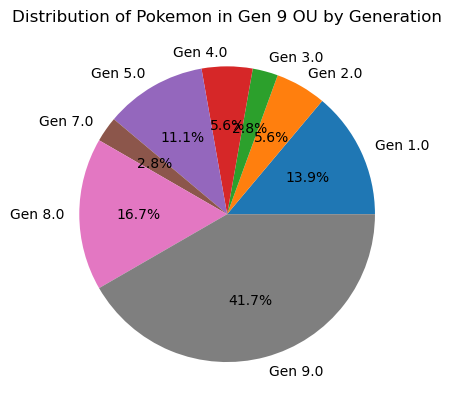

In [45]:
gen_counts = ou_df["Generation"].value_counts().sort_index()
labels = [f"Gen {g}" for g in gen_counts.index]

plt.pie(gen_counts.values, labels=labels, autopct="%1.1f%%")
plt.title("Distribution of Pokemon in Gen 9 OU by Generation")

Perhaps unsurprisingly, Gen 9 has the most Pokemon in it's OU generation. Between all the paradoxes and monsters like Gholdengo, this is fairly expected. What is surprising is absolutely no Pokemon from Gen 6.

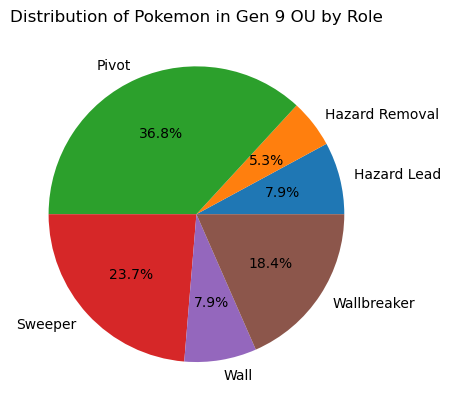

In [46]:
role_counts = ou_df["Role"].value_counts().sort_index()

plt.pie(role_counts.values, labels=role_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Pokemon in Gen 9 OU by Role")
plt.show()

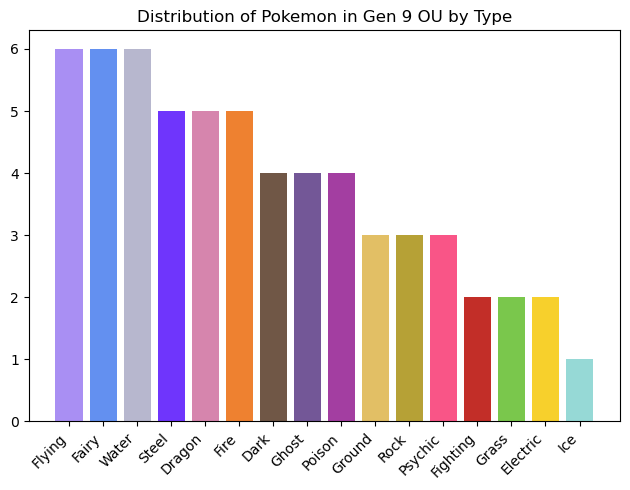

In [47]:
#type plot

type_colors = [
    "#A98FF3",  # Flying
    "#6390F0",  # Water
    "#B7B7CE",  # Steel
    "#6F35FC",  # Dragon
    "#D685AD",  # Fairy
    "#EE8130",  # Fire
    "#705746",  # Dark
    "#735797",  # Ghost
    "#A33EA1",  # Poison
    "#E2BF65",  # Ground
    "#B6A136",  # Rock
    "#F95587",  # Psychic
    "#C22E28",  # Fighting
    "#7AC74C",  # Grass
    "#F7D02C",  # Electric
    "#96D9D6",  # Ice
]
plt.bar(type_counts.index, type_counts.values, color=type_colors)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Distribution of Pokemon in Gen 9 OU by Type")
plt.show()



There are absolutely ZERO normal types in Gen 9 OU.

First version of the team recommender will just be a basic heuristics recommendation system.

In [100]:

def team_recommender_basic(favorite_pokemon, df):
    required_roles = {"Hazard Removal", "Hazard Lead", "Wallbreaker", "Pivot", "Sweeper"}
    roles_covered = set()
    types_covered = set()
    team = []
    team_set = set()

    #HELPERS
    def get_row(mon):
        row = df[df["Pokemon"] == mon]
        if row.empty:
            return None
        return row.iloc[0]

    def extract_roles(row):
        r = set()
        role = row.get("Role", None)
        if role is not None and str(role).lower() != "nan":
            r.add(str(role))
        return r
    
    def extract_types(row):
        t = set()
        t1 = row.get("Type 1", None)
        t2 = row.get("Type 2", None)
        if t1 is not None and str(t1).lower() != "nan":
            t.add(str(t1))
        if t2 is not None and str(t2).lower() != "nan":
            t.add(str(t2))
        t.discard(None)
        t.discard("")
        return t
    
    def candidate_scoring(row, roles_covered, types_covered):
        score = 0
        candidate_roles = extract_roles(row)
        candidate_types = extract_types(row)

        if len((required_roles - roles_covered) & candidate_roles) > 0:
            score += 5
        if len(candidate_roles - roles_covered) > 0:
            score += 2
        score += 2 * len(candidate_types - types_covered)
        if "Usage" in row.index:
            try:
                score += 0.05 * float(row["Usage"])
            except:
                pass
        return score, candidate_roles, candidate_types
    
    seed_pokemon = get_row(favorite_pokemon)
    if seed_pokemon is None:
        raise ValueError(f"{favorite_pokemon} not found in the dataset")
    
    team.append(favorite_pokemon)
    team_set.add(favorite_pokemon)

    seed_roles = extract_roles(seed_pokemon)
    seed_types = extract_types(seed_pokemon)
    roles_covered |= seed_roles
    types_covered |= seed_types

    while len(team) < 6:
        best_pokemon = None
        best_score = float('-inf')
        best_roles = set()
        best_types = set()

        for _, row in df.iterrows():
            pokemon = row["Pokemon"]
            if pokemon in team_set:
                continue
            score, candidate_roles, candidate_types = candidate_scoring(row, roles_covered, types_covered)
            if score > best_score:
                best_score = score
                best_pokemon = pokemon
                best_roles = candidate_roles
                best_types = candidate_types
        if best_pokemon is None:
            break

        team.append(best_pokemon)
        team_set.add(best_pokemon)
        roles_covered |= best_roles
        types_covered |= best_types

    return team











In [101]:
team = team_recommender_basic("Chimchar", with_roles)
team

['Chimchar', 'Great Tusk', 'Kingambit', 'Gholdengo', 'Dragapult', 'Glimmora']